In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

# -------------------------
# Função para simular MDM/DLM
# -------------------------
def simulate_mdm(T, W, V, dag_edges, n_nodes):
    """
    T        : tamanho da série
    W        : variância do sistema (coeficientes theta)
    V        : variância observacional
    dag_edges: lista de tuplas (pai, filho)
    n_nodes  : número de nós
    """
    theta = np.zeros((T, n_nodes, n_nodes))  # theta[t,r,i] = coef pai i -> r
    Y = np.zeros((T, n_nodes))

    for t in range(1, T):
        # atualizar coeficientes theta
        theta[t] = theta[t-1] + np.random.normal(0, np.sqrt(W), size=(n_nodes,n_nodes))
        
        # atualizar observações
        for r in range(n_nodes):
            val = 0
            for (i,j) in dag_edges:
                if j == r:
                    val += theta[t,r,i] * Y[t-1,i]
            val += np.random.normal(0, np.sqrt(V))
            Y[t,r] = val
    return pd.DataFrame(Y, columns=[f"Y{r+1}" for r in range(n_nodes)])

# -------------------------
# Função para plotar DAG
# -------------------------
def plot_dag(dag_edges, node_names, title="DAG"):
    """
    dag_edges : lista de tuplas (pai, filho)
    node_names: lista de nomes dos nós
    """
    n = len(node_names)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    positions = {name: (np.cos(a), np.sin(a)) for name,a in zip(node_names, angles)}

    plt.figure(figsize=(6,6))
    # plot nodes
    for name, (x,y) in positions.items():
        plt.scatter(x, y, s=1000)
        plt.text(x, y, name, ha="center", va="center", fontsize=12, color="white")
    
    # plot edges
    for (parent, child) in dag_edges:
        x1, y1 = positions[node_names[parent]]
        x2, y2 = positions[node_names[child]]
        plt.arrow(x1, y1, 0.85*(x2-x1), 0.85*(y2-y1),
                  head_width=0.05, length_includes_head=True)
    
    plt.title(title)
    plt.axis("off")
    plt.show()

# -------------------------
# Função para plotar séries temporais
# -------------------------
def plot_time_series(df, title="Séries Temporais"):
    n = df.shape[1]
    fig, axes = plt.subplots(n,1,figsize=(10,2.5*n), sharex=True)
    if n==1:
        axes = [axes]
    for ax, col in zip(axes, df.columns):
        ax.plot(df[col])
        ax.set_title(col)
        ax.grid(True)
    plt.xlabel("Tempo")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



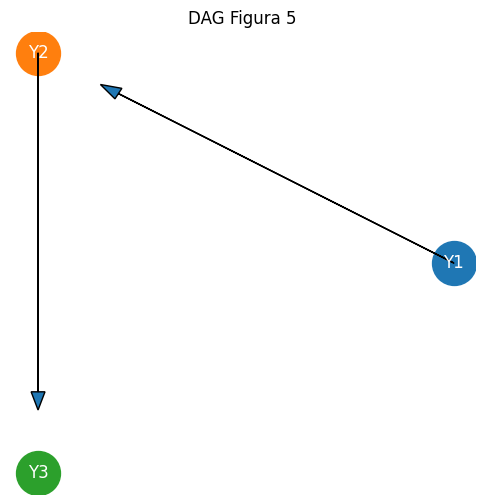

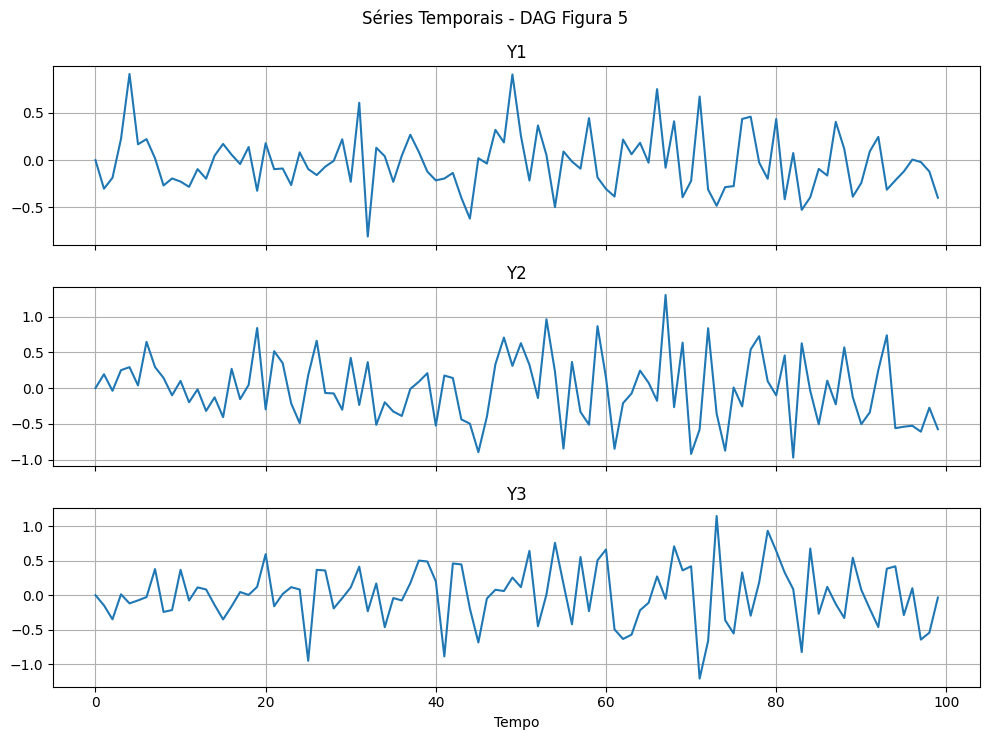

Arquivo salvo: DAG_Figura5.csv


In [4]:
T = 100       # tamanho da série
W = 0.01      # variância do sistema (theta)
V = 0.1       # variância observacional

# --- DAG Figura 5 ---
n_nodes5 = 3
node_names5 = [f"Y{i+1}" for i in range(n_nodes5)]
dag5_edges = [(0,1),(1,2)]  # 1→2→3

df5 = simulate_mdm(T, W, V, dag5_edges, n_nodes5)
plot_dag(dag5_edges, node_names5, title="DAG Figura 5")
plot_time_series(df5, title="Séries Temporais - DAG Figura 5")
df5.to_csv("DAG_Figura5.csv", index=False)
print("Arquivo salvo: DAG_Figura5.csv")




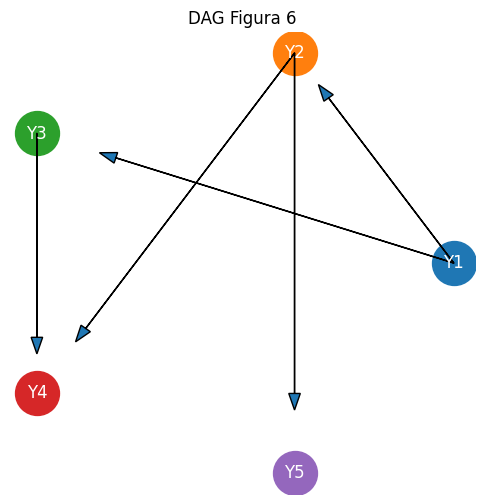

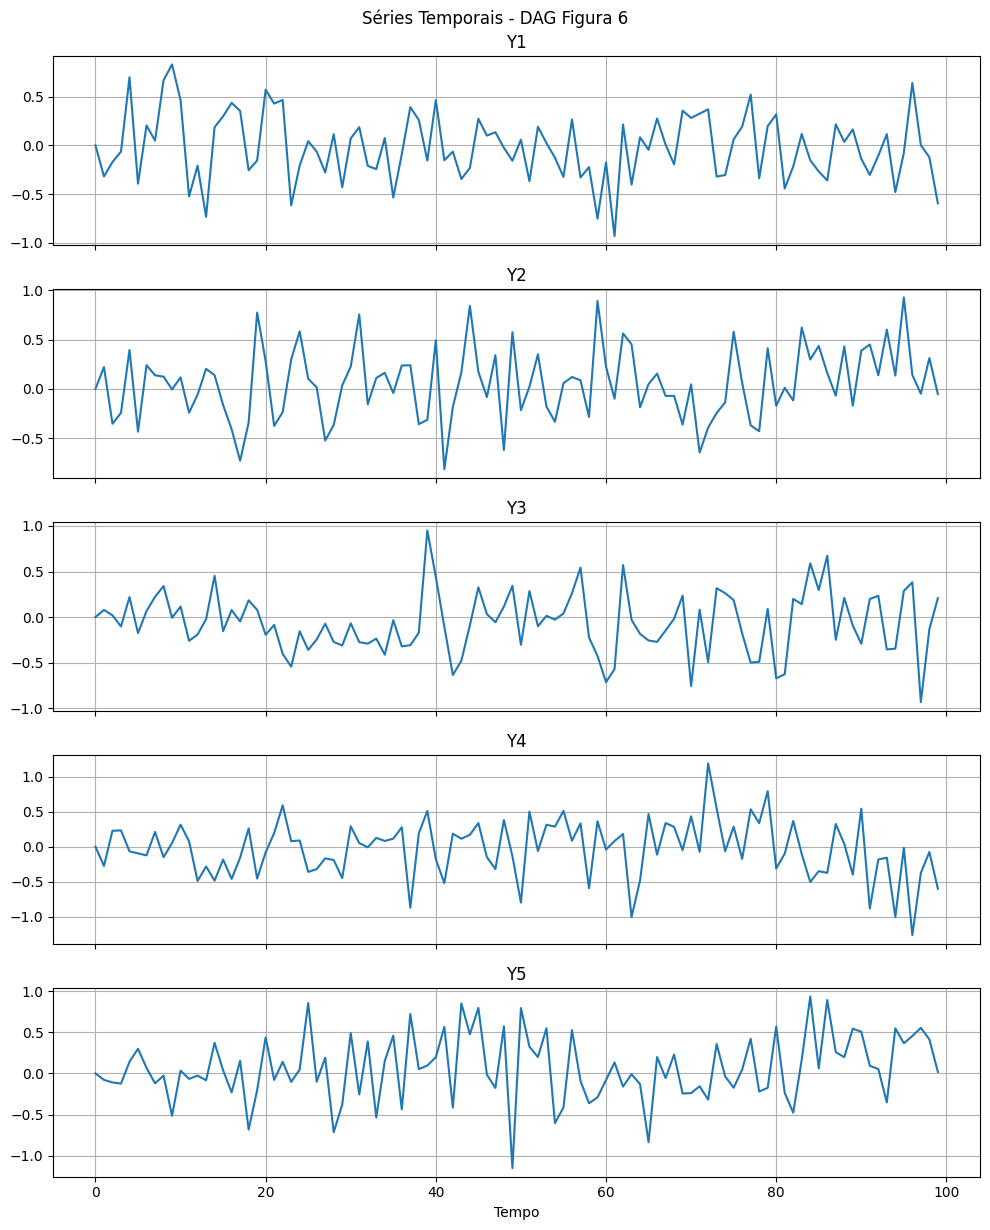

Arquivo salvo: DAG_Figura6.csv


In [5]:
# --- DAG Figura 6 ---
n_nodes6 = 5
node_names6 = [f"Y{i+1}" for i in range(n_nodes6)]
dag6_edges = [(0,1),(0,2),(1,3),(2,3),(1,4)]  # 1→2,1→3,2→4,3→4,2→5

df6 = simulate_mdm(T, W, V, dag6_edges, n_nodes6)
plot_dag(dag6_edges, node_names6, title="DAG Figura 6")
plot_time_series(df6, title="Séries Temporais - DAG Figura 6")
df6.to_csv("DAG_Figura6.csv", index=False)
print("Arquivo salvo: DAG_Figura6.csv")